In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
df = pd.read_csv("sales_data.csv")

In [54]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [56]:
df.shape

(1000, 14)

In [57]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


In [58]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

In [61]:
df['Month'] = df['Sale_Date'].dt.month_name()

In [62]:
df['Year'] = df['Sale_Date'].dt.year

In [63]:
df['Profit'] = (df['Unit_Price'] - df['Unit_Cost']*df['Quantity_Sold'])

In [64]:
total_sales = df['Sales_Amount'].sum()

In [65]:
total_profit = df['Profit'].sum()

In [66]:
total_quantity = df['Quantity_Sold'].sum()

In [67]:
avg_order = df['Sales_Amount'].mean()

In [68]:
monthly_sales = df.groupby('Month')['Sales_Amount'].sum()

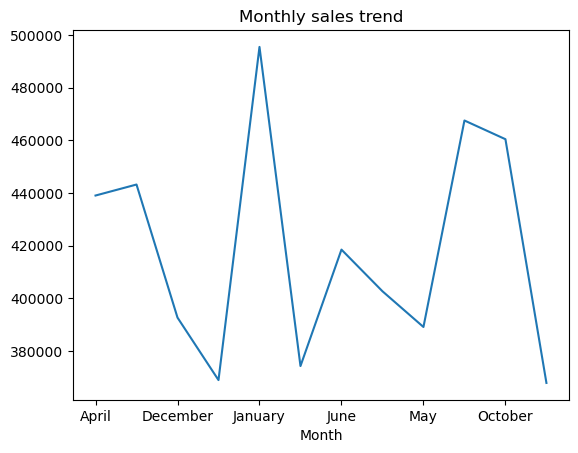

In [69]:
monthly_sales.plot(kind='line')
plt.title("Monthly sales trend")
plt.show()

In [70]:
category_sales = df.groupby('Product_Category')['Sales_Amount'].sum()

In [71]:
category_sales.sort_values(ascending=False)

Product_Category
Clothing       1313474.36
Furniture      1260517.69
Electronics    1243499.64
Food           1201773.54
Name: Sales_Amount, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

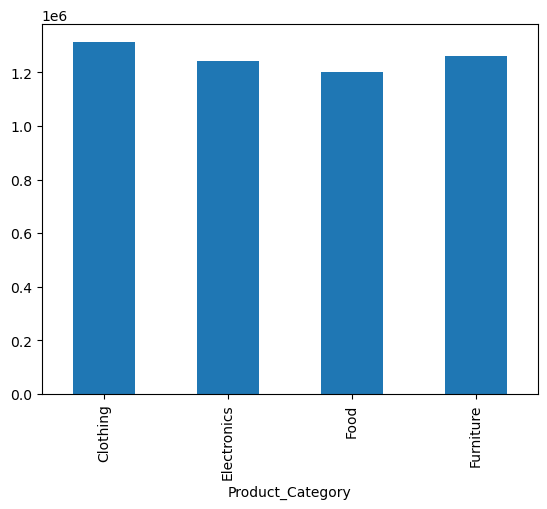

In [72]:
category_sales.plot(kind='bar')
plt.show

In [73]:
region_sales = df.groupby('Region')['Sales_Amount'].sum()

In [74]:
region_profit = df.groupby('Region')['Profit'].sum()

In [75]:
rep_sales = df.groupby('Sales_Rep')['Sales_Amount'].sum()

In [76]:
rep_sales.sort_values(ascending=False).head(10)

Sales_Rep
David      1141737.36
Bob        1080990.63
Eve         970183.99
Alice       965541.77
Charlie     860811.48
Name: Sales_Amount, dtype: float64

In [77]:
customer_sales = df.groupby('Customer_Type')['Sales_Amount'].sum()

In [78]:
payment_sales = df.groupby('Payment_Method')['Sales_Amount'].sum()

In [79]:
channel_sales = df.groupby('Sales_Channel')['Sales_Amount'].sum()

In [80]:
df['Discount'].mean()

np.float64(0.15239)

In [81]:
df.groupby('Discount')['Sales_Amount'].mean()

Discount
0.00    4511.495000
0.01    5103.344324
0.02    4435.165833
0.03    5604.861282
0.04    5234.551053
0.05    5741.821923
0.06    4432.347419
0.07    4599.938485
0.08    4967.657742
0.09    4794.341316
0.10    4660.425405
0.11    4501.740909
0.12    4818.418462
0.13    5466.360000
0.14    5205.207742
0.15    4551.299655
0.16    4417.704762
0.17    4581.471429
0.18    4236.705357
0.19    5443.487407
0.20    6005.017692
0.21    4725.838462
0.22    5573.047500
0.23    6012.968929
0.24    5668.595000
0.25    4313.914000
0.26    5619.080000
0.27    4429.965946
0.28    4589.708148
0.29    5311.076061
0.30    5300.125556
Name: Sales_Amount, dtype: float64

In [82]:
df.groupby('Region')['Sales_Amount'] \
.sum() \
.sort_values(ascending=False) \
.head(5)

Region
North    1369612.51
East     1259792.93
West     1235608.93
South    1154250.86
Name: Sales_Amount, dtype: float64

In [83]:
df.groupby('Region')['Sales_Amount'] \
.sum() \
.sort_values() \
.head(5)

Region
South    1154250.86
West     1235608.93
East     1259792.93
North    1369612.51
Name: Sales_Amount, dtype: float64

In [84]:
df.groupby('Product_Category')['Profit'] \
.sum() \
.sort_values(ascending=False)

Product_Category
Food          -13120112.15
Electronics   -15309099.54
Furniture     -15839962.41
Clothing      -16844479.42
Name: Profit, dtype: float64

In [85]:
df.groupby('Sales_Rep')['Profit'] \
.sum() \
.sort_values(ascending=False)

Sales_Rep
Charlie   -10020307.92
Alice     -11576497.57
Bob       -11976873.67
Eve       -13226780.29
David     -14313194.07
Name: Profit, dtype: float64

Text(0.5, 0.98, 'Sales Data Analysis Dashboard')

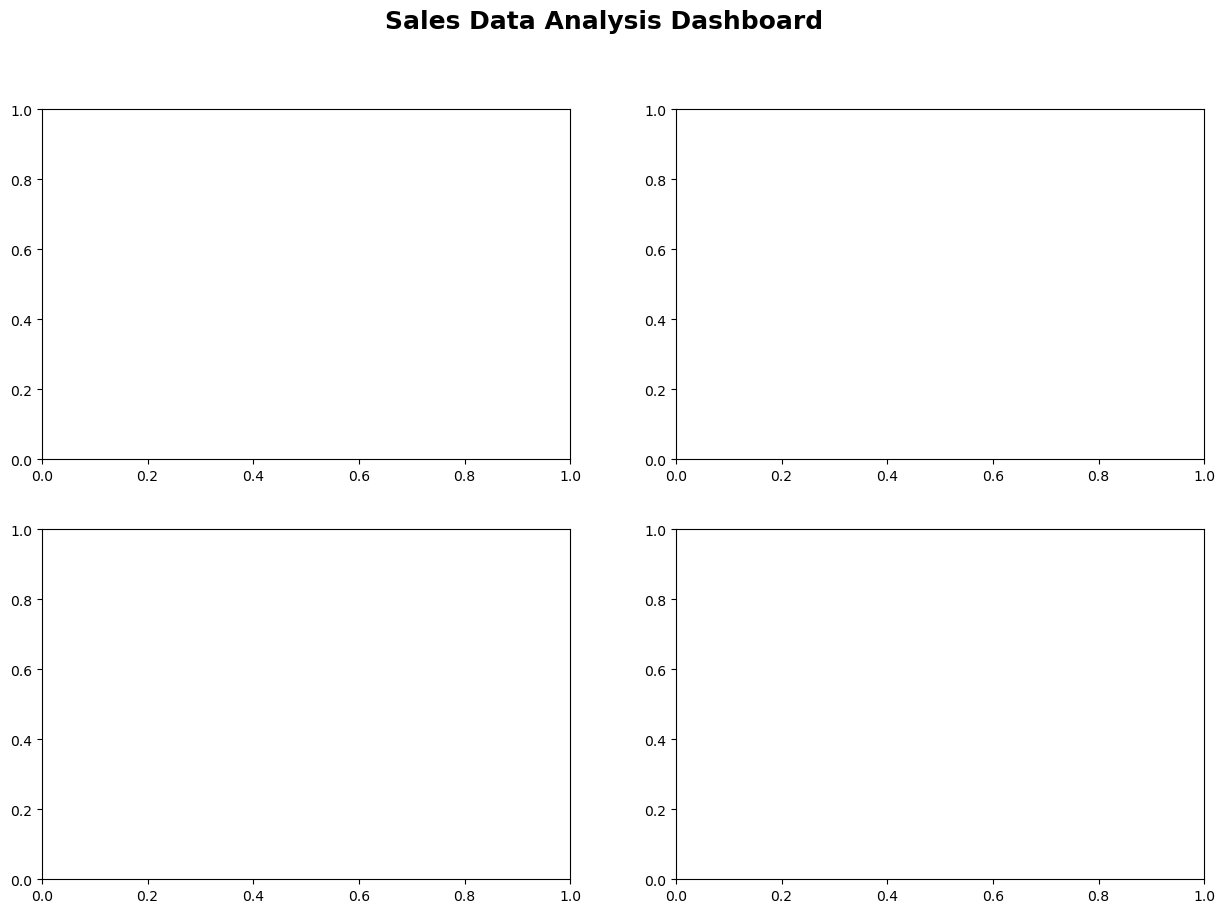

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

fig.suptitle('Sales Data Analysis Dashboard',
             fontsize=18,
             fontweight='bold')


In [87]:
axes[0,0].plot(monthly_sales.index,
               monthly_sales.values)

axes[0,0].set_title('Monthly Sales Trend')
axes[0,0].tick_params(axis='x', rotation=45)

In [88]:
axes[0,1].bar(region_sales.index,
              region_sales.values)

axes[0,1].set_title('Sales by Region')
axes[0,1].tick_params(axis='x', rotation=45)

In [89]:
axes[1,0].bar(category_sales.index,
              category_sales.values)

axes[1,0].set_title('Product Category Sales')
axes[1,0].tick_params(axis='x', rotation=45)

In [90]:
axes[1,1].pie(channel_sales.values,
              labels=channel_sales.index,
              autopct='%1.1f%%')

axes[1,1].set_title('Sales Channel Distribution')


Text(0.5, 1.0, 'Sales Channel Distribution')

In [91]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

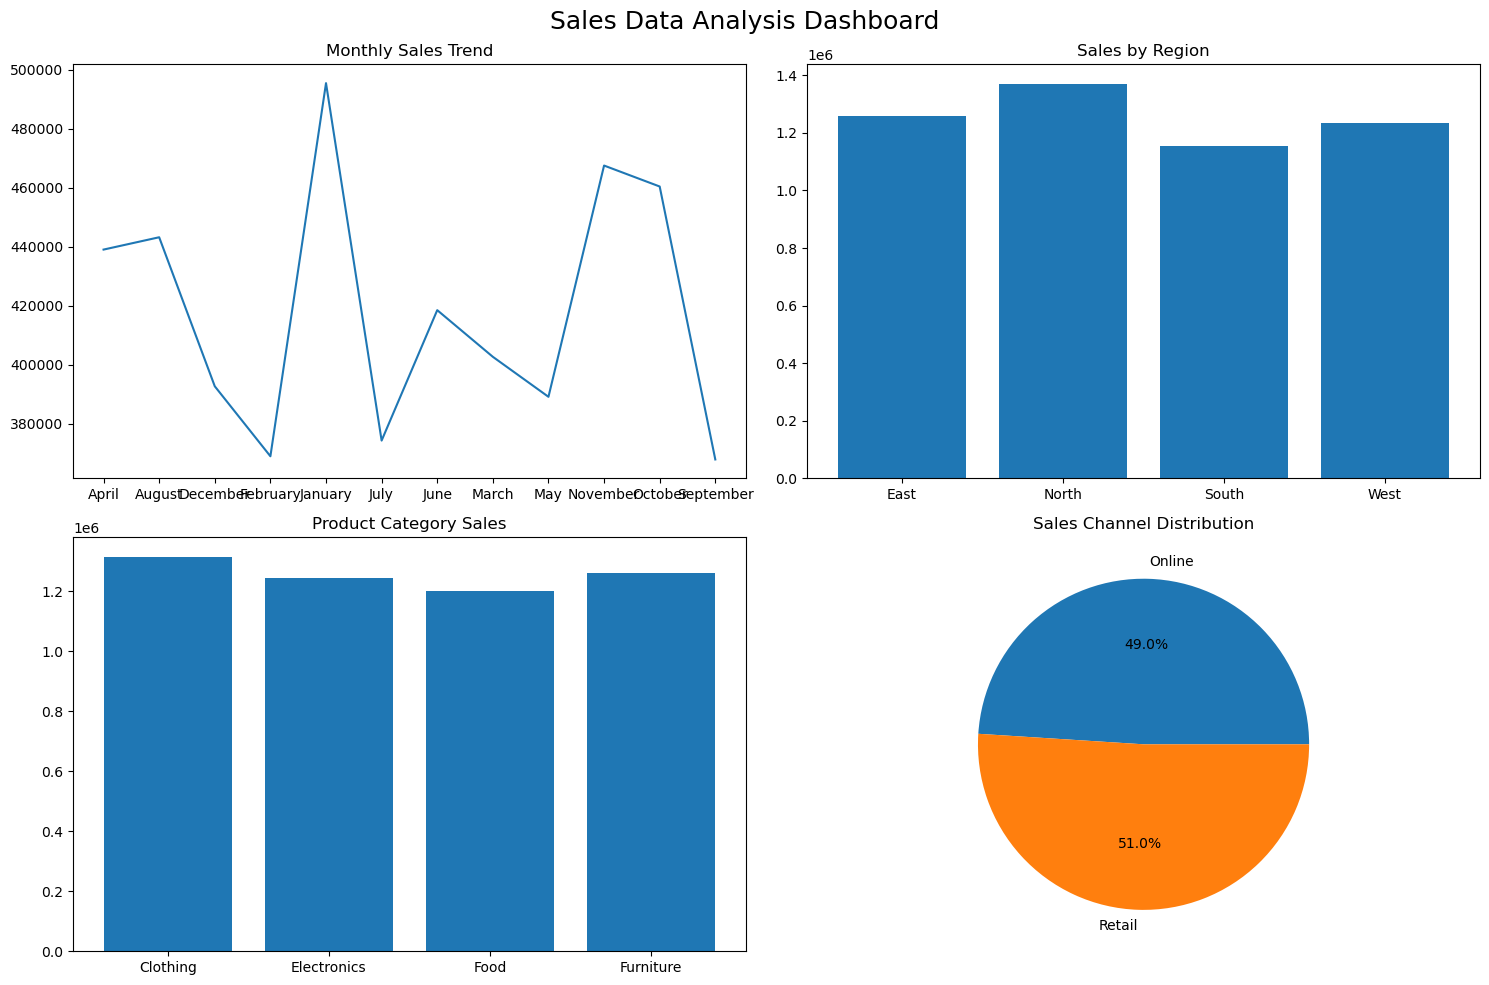

In [92]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

fig.suptitle('Sales Data Analysis Dashboard', fontsize=18)

axes[0,0].plot(monthly_sales.index, monthly_sales.values)
axes[0,0].set_title('Monthly Sales Trend')

axes[0,1].bar(region_sales.index, region_sales.values)
axes[0,1].set_title('Sales by Region')

axes[1,0].bar(category_sales.index, category_sales.values)
axes[1,0].set_title('Product Category Sales')

axes[1,1].pie(channel_sales.values,
              labels=channel_sales.index,
              autopct='%1.1f%%')
axes[1,1].set_title('Sales Channel Distribution')

plt.tight_layout()
plt.show()

In [93]:
summary = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Profit',
        'Total Quantity Sold',
        'Average Order Value'
    ],
    'Value': [
        total_sales,
        total_profit,
        total_quantity,
        avg_order
    ]
})

summary

,Metric,Value
0,Total Sales,5.019265e+06
1,Total Profit,-6.111365e+07
2,Total Quantity Sold,2.535500e+04
3,Average Order Value,5.019265e+03


In [94]:
plt.savefig("sales_dashboard.png",
            bbox_inches='tight',
            dpi=300)

<Figure size 640x480 with 0 Axes>